In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

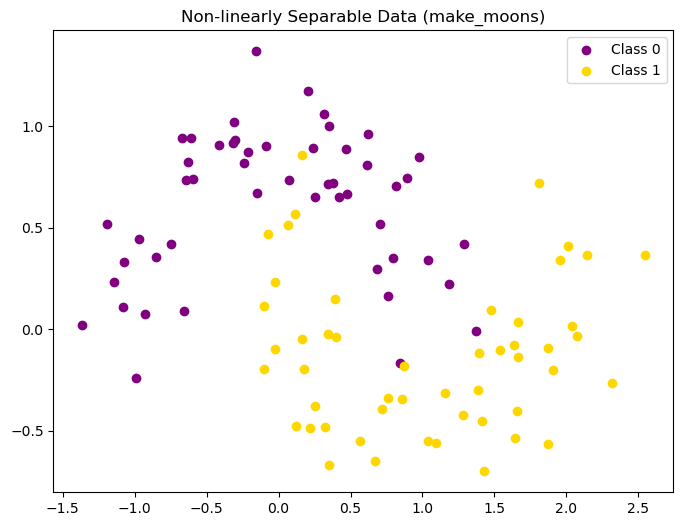

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=100, noise=0.2, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='purple', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='gold', label='Class 1')
plt.legend()
plt.title("Non-linearly Separable Data (make_moons)")
plt.show()


In [5]:
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression()

In [6]:
lg.fit(X, y)

LogisticRegression()

<Axes: >

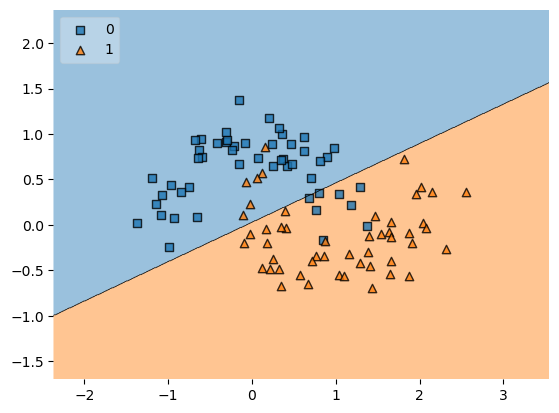

In [8]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X, y.astype('int'), lg, legend=2)

In [10]:

from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(lg,X,y,scoring='accuracy',cv=10))

0.8699999999999999

In [21]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 5 , include_bias = False)
X_trf = poly.fit_transform(X)

In [22]:
clf1 = LogisticRegression()
np.mean(cross_val_score(clf1,X_trf,y,scoring='accuracy',cv=10))

0.9200000000000002

In [17]:
def plot_decision_boundary(X,y,degree=1):
    
    poly = PolynomialFeatures(degree=degree)
    X_trf = poly.fit_transform(X)
    
    clf = LogisticRegression()
    clf.fit(X_trf,y)
    
    accuracy = np.mean(cross_val_score(clf,X_trf,y,scoring='accuracy',cv=10))
    
    a=np.arange(start=X[:,0].min()-1, stop=X[:,0].max()+1, step=0.01)
    b=np.arange(start=X[:,1].min()-1, stop=X[:,1].max()+1, step=0.01)


    XX,YY=np.meshgrid(a,b)
    
    input_array=np.array([XX.ravel(),YY.ravel()]).T

    labels=clf.predict(poly.transform(input_array))
    
    plt.contourf(XX,YY,labels.reshape(XX.shape),alpha=0.5)
    plt.scatter(X[:,0],X[:,1], c=y)
    plt.title('Degree = {}, accuracy is {}'.format(degree,np.round(accuracy,4)))

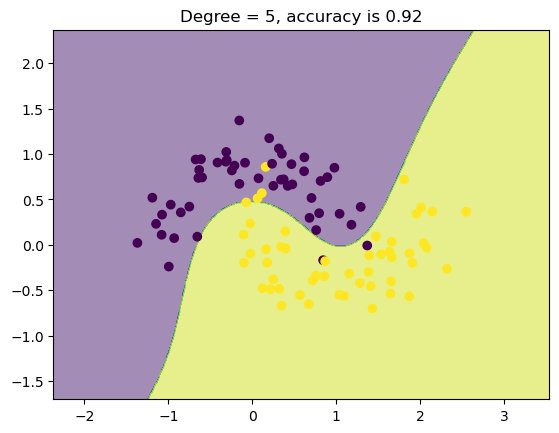

In [20]:
plot_decision_boundary(X , y , 5)